# Set up
importing data, setting up globals, and helper functions for fitting

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit

palette = sns.color_palette("husl", 8)
pv, pyr = pd.read_excel('results_drugs.xlsx', sheet_name="PV"), pd.read_excel('results_drugs.xlsx', sheet_name="pyramidal")
distances = [50, 100, 250, 750]
intensities = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
def sigmoid(x, L, x0, k):
    return L / (1 + np.exp(k * (x - x0)))

def gauss(x, I, R, sigma):
    p=2
    return np.exp(-x**2 / (sigma +(R * I)**p))


getting the mean probability of spiking $y$ at a distance $x$

In [200]:
pyr_data, pv_data = {}, {}

for intensity in pyr["Intensity"].unique():
    pyr_subset = pyr[pyr["Intensity"] == intensity]
    pv_subset = pv[pv["Intensity"] == intensity]

    y1, y1err, y2, y2err = [], [], [], []

    for dist in distances:
        value1 = pyr_subset[pyr_subset["Distance"] == dist]["mean_Spp"]
        mean1 = value1.mean()
        std1 = value1.std()
        y1.append(1 if np.isnan(mean1) else mean1)
        y1err.append(0.5 if np.isnan(std1) else std1)

        value2 = pv_subset[pv_subset["Distance"] == dist]["mean_Spp"]
        mean2 = value2.mean()
        std2 = value2.std()
        y2.append(1 if np.isnan(mean1) else mean1)
        y2err.append(0.5 if np.isnan(std2) else std2)

    pyr_data[intensity] = {
        "x": np.array([63.8, 107.9, 272.2, 727]),
        "xerr": np.array([13, 13, 24, 43]),
        "y": np.array(y1),
        "yerr": np.array(y1err),
    }

    pv_data[intensity] = {
        "x": np.array([60.8, 95.8, 248.5, 749]),
        "xerr": np.array([14, 20.1, 17, 23]),
        "y": np.array(y2),
        "yerr": np.array(y2err)
    }


Plotting the cleaned up data above at every intensity.

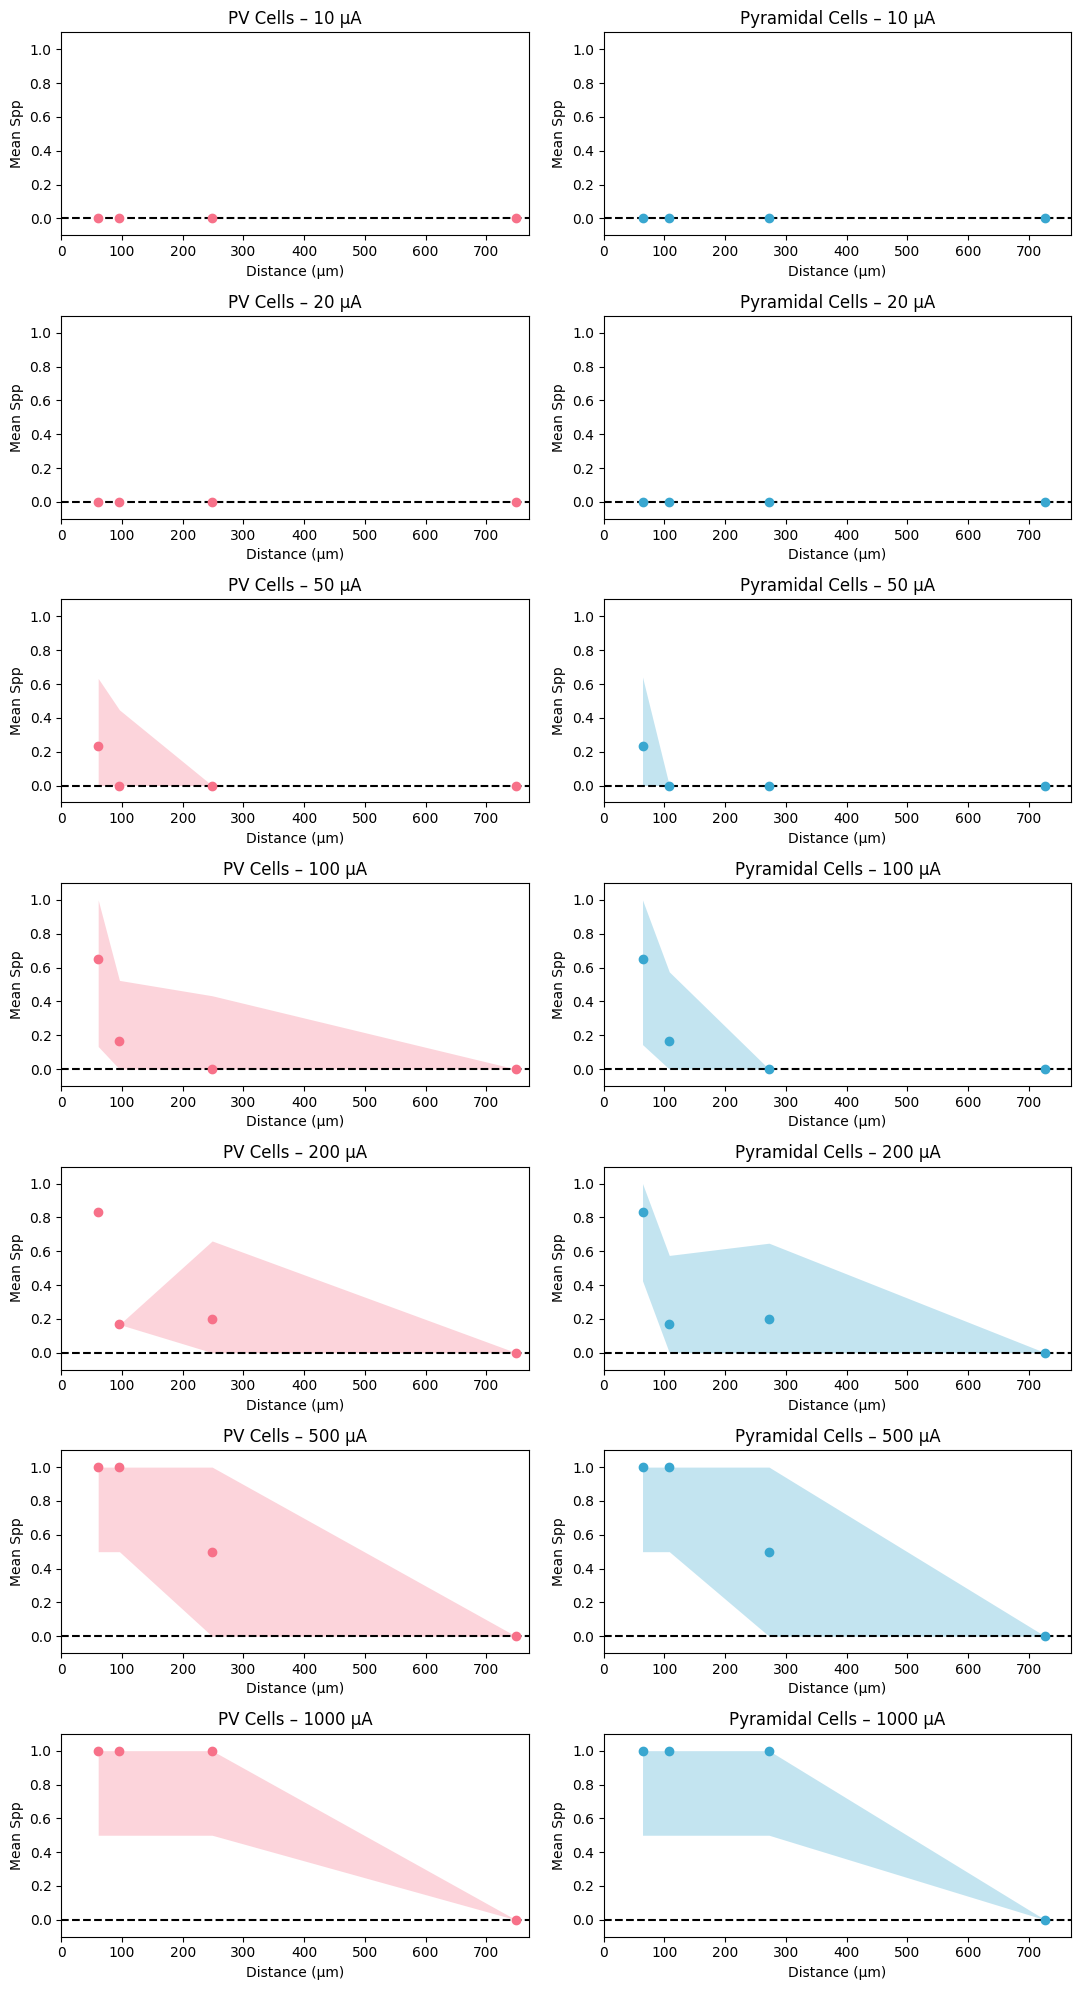

In [208]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 20))

axes = axes.flatten()  # make indexing easier

count = 0
for intensity in intensities:
    ax = axes[count]
    data = pv_data[intensity]
    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]
    yerr = yerr[idx]

    ax.scatter(x, y, color=palette[0], zorder=3, label='Mean')
    
    y_low  = np.clip(y - yerr, 0, 1)
    y_high = np.clip(y + yerr, 0, 1)
    ax.fill_between(
        x,
        y_low,
        y_high,
        color=palette[0],
        alpha=0.3,
        linewidth=0
    )
    ax.set_title(f'PV Cells – {intensity*1000:.0f} μA')
    ax.hlines(y=0, xmin=0, xmax=770, colors='k', linestyles='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_xlabel('Distance (μm)')
    ax.set_ylabel('Mean Spp')

    count += 1
    ax = axes[count]
    data = pyr_data[intensity]
    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]
    yerr = yerr[idx]

    y_low  = np.clip(y - yerr, 0, 1)
    y_high = np.clip(y + yerr, 0, 1)

    ax.scatter(x, y, color=palette[5], zorder=3, label='Mean')
    ax.fill_between(
        x,
        y_low,
        y_high,
        color=palette[5],
        alpha=0.3,
        linewidth=0
    )
    ax.set_title(f'Pyramidal Cells – {intensity*1000:.0f} μA')
    ax.hlines(y=0, xmin=0, xmax=770, colors='k', linestyles='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_xlabel('Distance (μm)')
    ax.set_ylabel('Mean Spp')
    count += 1


plt.tight_layout()
plt.show()

# FITTING

helper function to guess the best fit to the data with the sigmoidal function.

In [16]:
def best_guess(x, y):
    """Estimate initial parameters for sigmoid fitting."""
    L = np.max(y)
    x0 = x[np.argmin(np.abs(y - 0.5))]
    k = 0.1  # A small positive value
    return [L, x0, k]

In [17]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    
    p0 = best_guess(x, y)
    
    try:
        params1, cov1 = curve_fit(sigmoid, x, y)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    p0 = best_guess(x, y)

    try:
        params2, cov2 = curve_fit(sigmoid, x, y, p0=p0)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2


PV: Optimal parameters not found: Number of calls to function has reached maxfev = 800.  for intensity 0.2
PV: Optimal parameters not found: Number of calls to function has reached maxfev = 800.  for intensity 0.5


/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3413892137.py:10: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(k * (x - x0)))
/Users/maxpiatine/Developer/thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3987552215.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params1, cov1 = curve_fit(sigmoid, x, y)
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3987552215.py:22: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, cov2 = curve_fit(sigmoid, x, y, p0=p0)


plotting best fit with the data

/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/3413892137.py:10: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(k * (x - x0)))


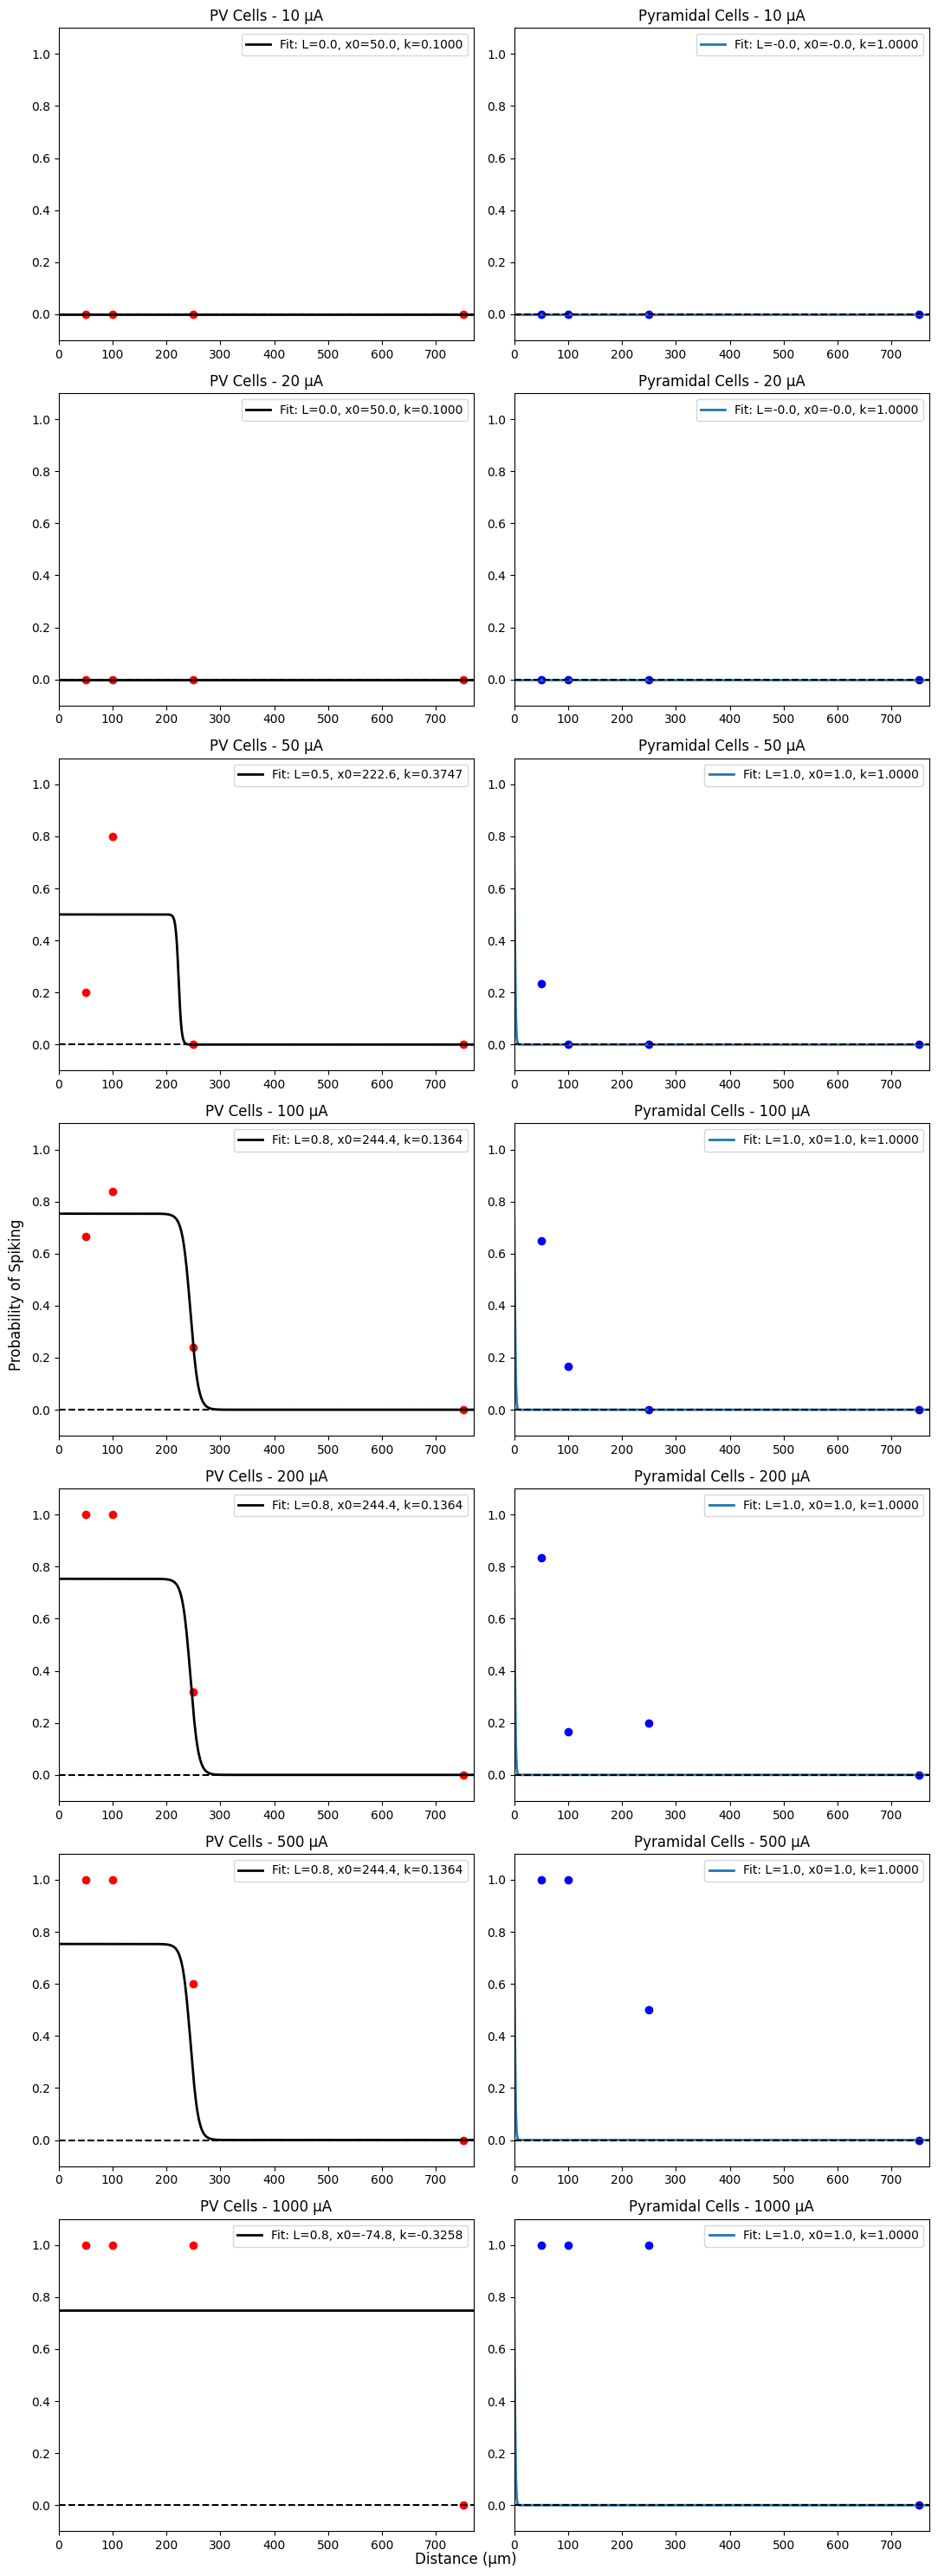

In [18]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    ax.scatter(distances, data["y"], color='red')

    L, x0, k = pv_fits[intensity]
    ax.plot(x_fit, sigmoid(x_fit, L, x0, k),
            label=f"Fit: L={L:.1f}, x0={x0:.1f}, k={k:.4f}",
            linewidth=2, color="k")
    
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    y = pyr_data[intensity]["y"]
    ax.scatter(distances, y, color='blue')

    L, x0, k = pyr_fits[intensity]
    ax.plot(x_fit, sigmoid(x_fit, L, x0, k),
            label=f"Fit: L={L:.1f}, x0={x0:.1f}, k={k:.4f}",
            linewidth=2)

    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()


## Gaussian attempt

with the standard deviation changes.

In [187]:
p=6
def gauss_fit(I):
    def model(x, R, sigma):
        return np.exp(-x**2 / (sigma + (R * I)**(2/p+2)))
    return model

/Users/maxpiatine/Developer/thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:982: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/Users/maxpiatine/Developer/thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:542: RuntimeWarning: invalid value encountered in multiply
  return transform * (func(xdata, *params) - ydata)
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4154189896.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0, sigma=yerr, absolute_sigma=True)
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4154189896.py:24: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0, sigma=yerr, absolute_sigma=True)


{np.float64(0.01): array([  0.5, 100. ]), np.float64(0.02): array([  0.5, 100. ]), np.float64(0.05): array([  0.5, 100. ]), np.float64(0.1): array([  0.5, 100. ]), np.float64(0.2): array([  0.5, 100. ]), np.float64(0.5): array([  0.5, 100. ]), np.float64(1.0): array([  0.5, 100. ])}


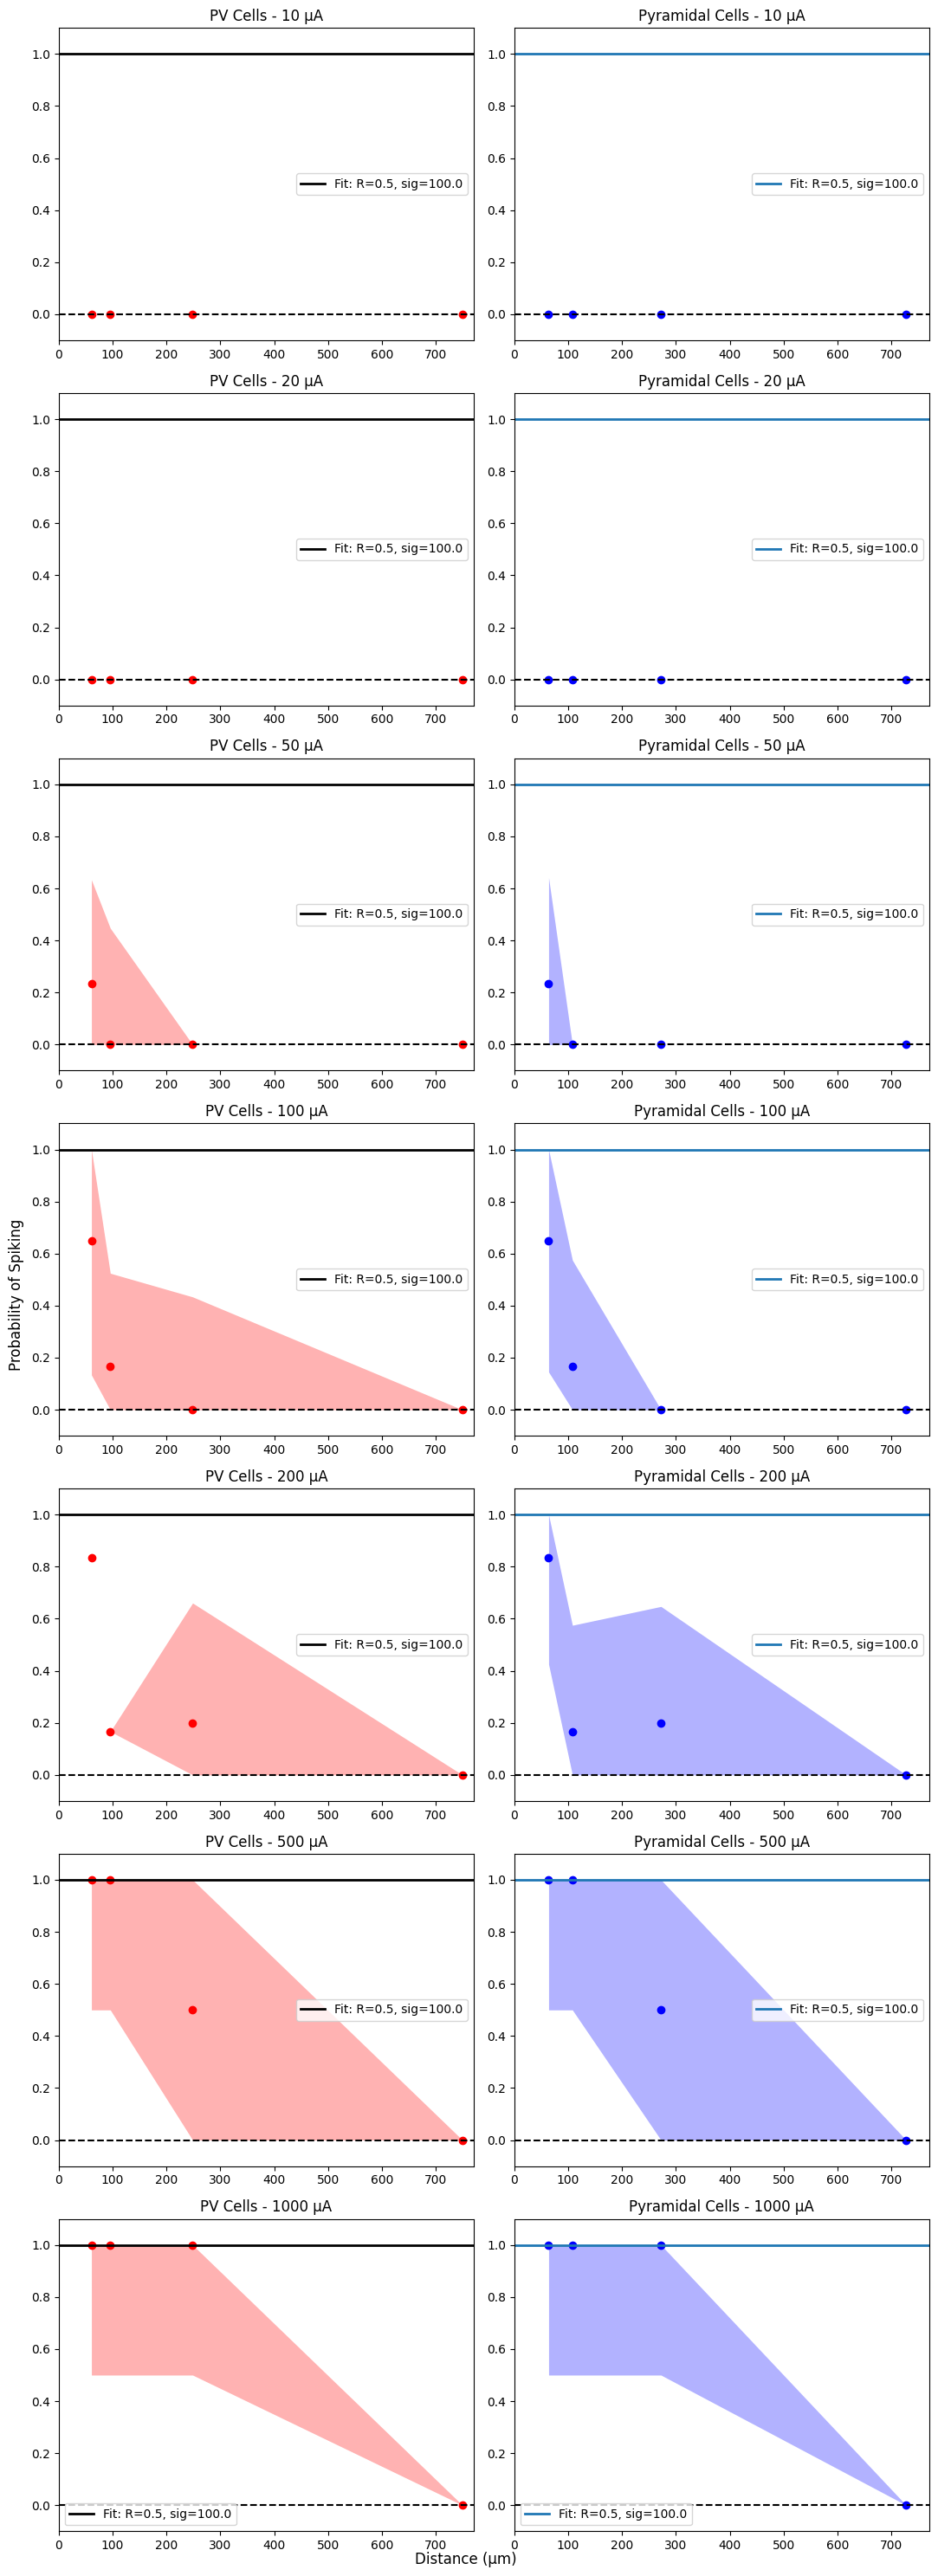

In [189]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    yerr = vals["yerr"]
    
    p0 = [0.5, 100]
    
    try:
        params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0, sigma=yerr, absolute_sigma=True)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    yerr = vals["yerr"]
    p0 = [0.5, 100]

    try:
        params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0=p0, sigma=yerr, absolute_sigma=True)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2

print(pv_fits)
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]
    ax.scatter(x, y, color='red')

    R, sigma = pv_fits[intensity]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, sigma),
            label=f"Fit: R={R:.1f}, sig={sigma:.1f}",
            linewidth=2, color="k")
    
    ax.axhline(0, color='k', linestyle='dashed')
    y_low  = np.clip(y - yerr, 0, 1)
    y_high = np.clip(y + yerr, 0, 1)
    ax.fill_between(
        x,
        y_low,
        y_high,
        color='red',
        alpha=0.3,
        linewidth=0
    )
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    data = pyr_data[intensity]
    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]
    ax.scatter(x, y, color='blue')

    R, sigma = pyr_fits[intensity]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, sigma),
            label=f"Fit: R={R:.1f}, sig={sigma:.1f}",
            linewidth=2)
    
    y_low  = np.clip(y - yerr, 0, 1)
    y_high = np.clip(y + yerr, 0, 1)
    ax.fill_between(
        x,
        y_low,
        y_high,
        color='blue',
        alpha=0.3,
        linewidth=0
    )
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()


# Maintaining $\sigma=100 \mu m$

without the std changes.

In [227]:
def gauss_fit(I):
    def model(x, R, p):
        return np.exp(-x**2 / (100+(R * I)**p))
    return model

def gauss(x, I, R, p):
    return np.exp(-x**2 / (100 +(R * I)**p))

/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4087091013.py:3: RuntimeWarning: invalid value encountered in scalar power
  return np.exp(-x**2 / (100+(R * I)**p))
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/412561890.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0)


{np.float64(0.01): array([1.43658548e-08, 3.87190859e-01]), np.float64(0.02): array([1.67756849e-08, 7.42992156e-01]), np.float64(0.05): array([0.82747276, 2.08954468]), np.float64(0.1): array([1.05434423, 1.88189487]), np.float64(0.2): array([2.10148172, 1.4889157 ]), np.float64(0.5): array([4.51170688, 1.48626957]), np.float64(1.0): array([0.81213043, 1.87185634])}


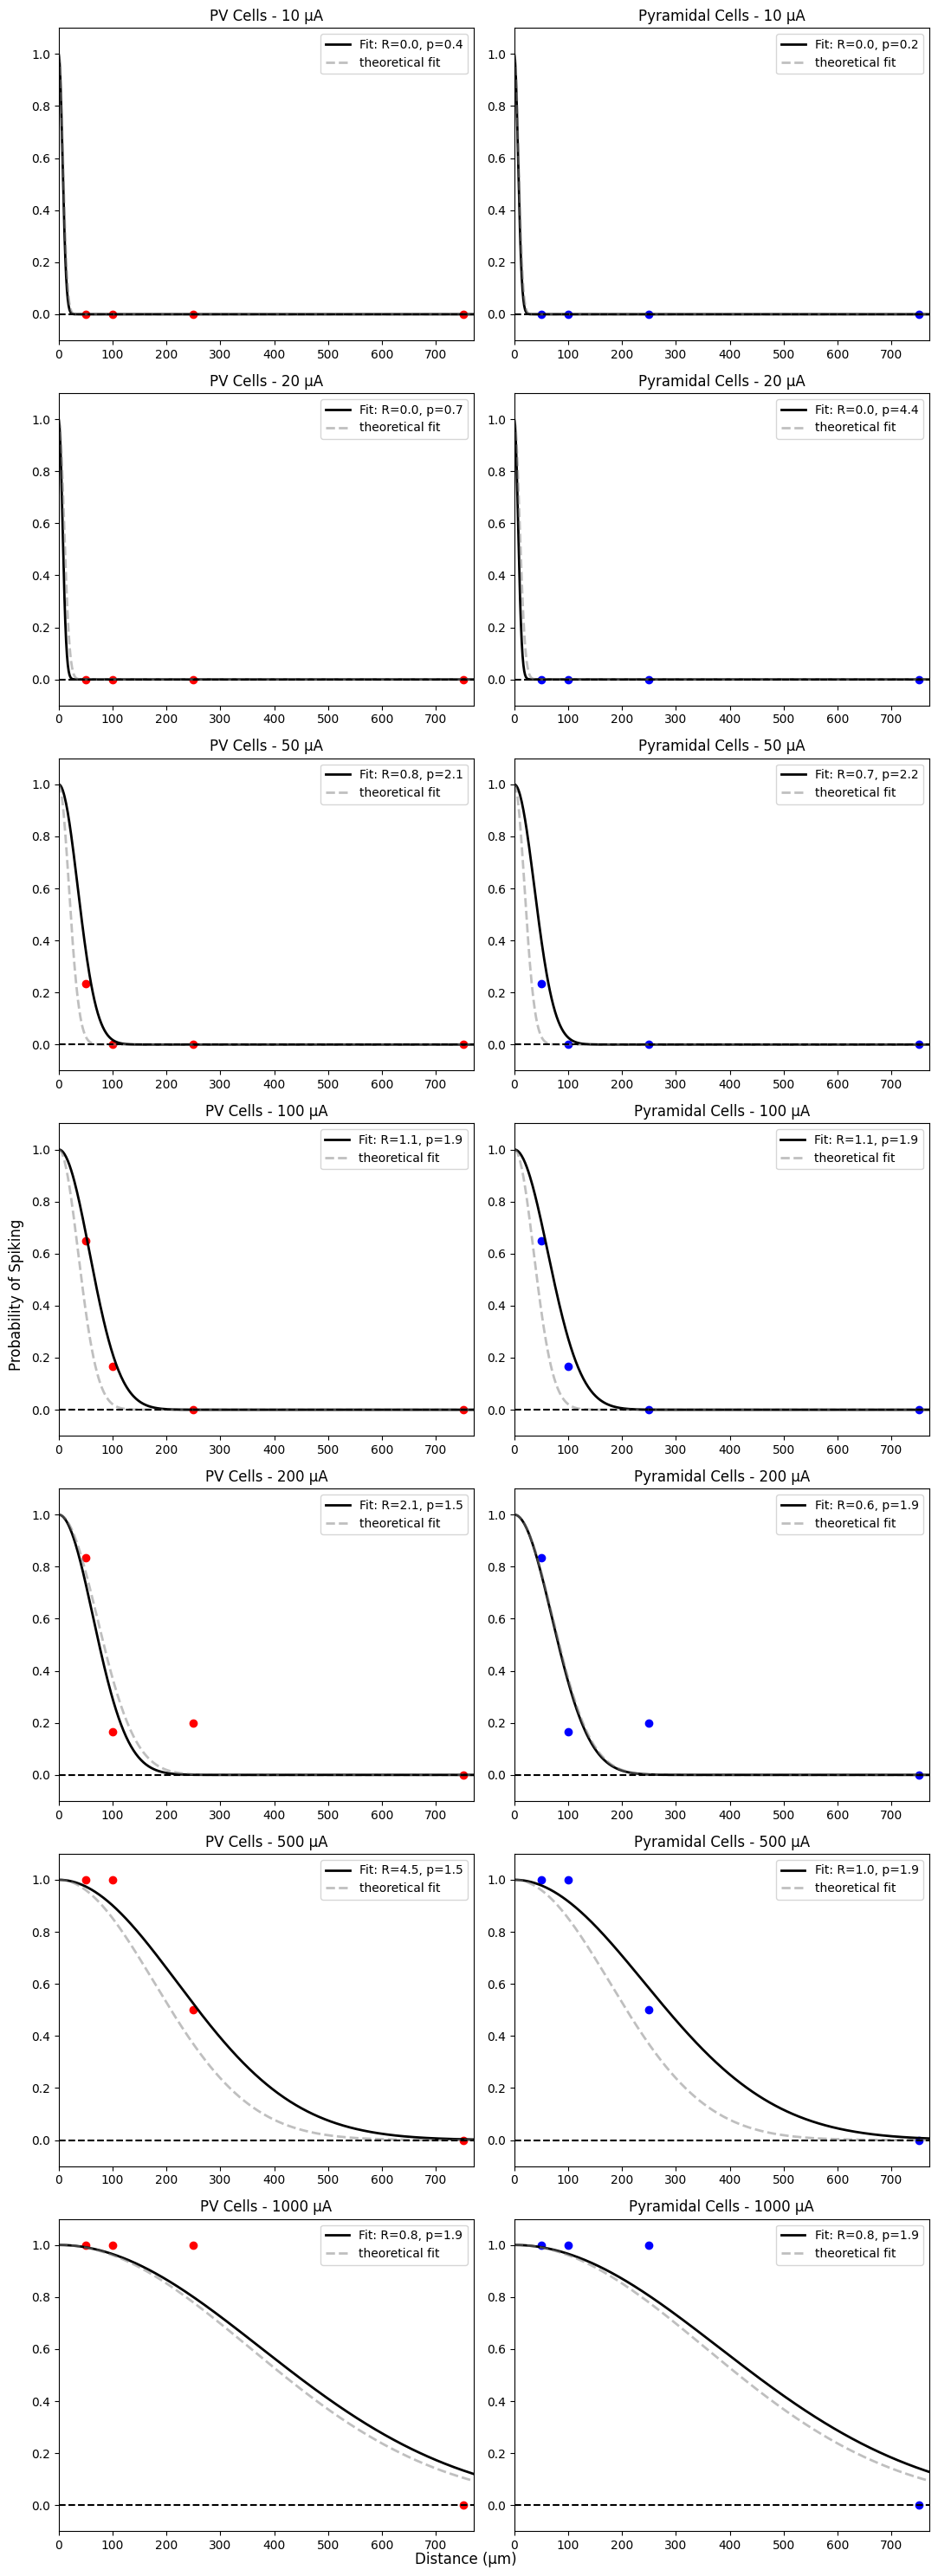

In [230]:
pyr_fits, pv_fits = {}, {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    
    p0 = [0.5, 2]
    
    try:
        params1, cov1 = curve_fit(gauss_fit(intensity*1000), x, y, p0)
    except RuntimeError as e: 
        print("Pyr:", e, " for intensity", intensity)
    
    pyr_fits[intensity] = params1

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    p0 = [0.5, 2]

    try:
        params2, cov2 = curve_fit(gauss_fit(intensity*1000), x, y, p0)
    except RuntimeError as e:
        print("PV:", e, " for intensity", intensity)
    
    pv_fits[intensity] = params2

print(pv_fits)
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    ax.scatter(distances, data["y"], color='red')

    R, p = pv_fits[intensity][0], pv_fits[intensity][1]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, p), label=f"Fit: R={R:.1f}, p={p:.1f}", linewidth=2, color="k")
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 2),
            label=f"theoretical fit",
            linewidth=2, color="gray", alpha=0.5, linestyle='dashed')
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    y = pyr_data[intensity]["y"]
    ax.scatter(distances, y, color='blue')

    R, p = pyr_fits[intensity][0], pyr_fits[intensity][1]
    ax.plot(x_fit, gauss(x_fit, intensity*1000, R, p), label=f"Fit: R={R:.1f}, p={p:.1f}", linewidth=2, color="k")
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 2),
            label=f"theoretical fit",
            linewidth=2, color="gray", alpha=0.5, linestyle='dashed')
    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()

In [219]:
def gauss_fit1(I):
    def model(x, R, p):
        return np.exp(-x**2 / (100**2+(R * I)**(2/(p+2))))
    return model

def gauss1(x, I, R, p):
    return np.exp(-x**2 / (100**2 +(R * I)**(2/(p+2))))

def gauss_fit2(I):
    def model(x, R, p):
        return np.exp(-x**2 / (100+(R * I)**(p)))
    return model

def gauss2(x, I, R, p):
    return np.exp(-x**2 / (100 +(R * I)**p))


In [234]:
pyr_fits1, pyr_fits2, pv_fits1, pv_fits2 = {}, {}, {}, {}

p0 = [0.5, 2]
for intensity, vals in pyr_data.items():
    x = vals["x"]
    y= vals["y"]
    yerr = vals["yerr"]
    
    try:
        params1, cov1 = curve_fit(gauss_fit1(intensity*1000), x, y, p0=p0)
    except RuntimeError as e: 
        print("gauss 1 Pyr:", e, " for intensity", intensity)
    
    try:
        params2, cov2 = curve_fit(gauss_fit2(intensity*1000), x, y, p0=p0)
    except RuntimeError as e: 
        print("gauss 2 Pyr:", e, " for intensity", intensity)

    pyr_fits1[intensity] = params1
    pyr_fits2[intensity] = params2

for intensity, vals in pv_data.items():
    x = vals["x"]
    y= vals["y"]
    yerr = vals["yerr"]

    try:
        params1, cov1 = curve_fit(gauss_fit1(intensity*1000), x, y, p0=p0)
    except RuntimeError as e:
        print("gauss 1 PV:", e, " for intensity", intensity)

    try:
        params2, cov2 = curve_fit(gauss_fit2(intensity*1000), x, y, p0=p0)
    except RuntimeError as e:
        print("gauss 2 PV:", e, " for intensity", intensity)
    
    pv_fits1[intensity] = params1
    pv_fits2[intensity] = params2

/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4280760635.py:3: RuntimeWarning: invalid value encountered in scalar power
  return np.exp(-x**2 / (100**2+(R * I)**(2/(p+2))))
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4280760635.py:11: RuntimeWarning: invalid value encountered in scalar power
  return np.exp(-x**2 / (100+(R * I)**(p)))
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4177864248.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, cov2 = curve_fit(gauss_fit2(intensity*1000), x, y, p0=p0)
/var/folders/fj/pq0251sj5ld5q6zfbcdblzkc0000gn/T/ipykernel_41360/4177864248.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  params1, cov1 = curve_fit(gauss_fit1(intensity*1000), x, y, p0=p0)


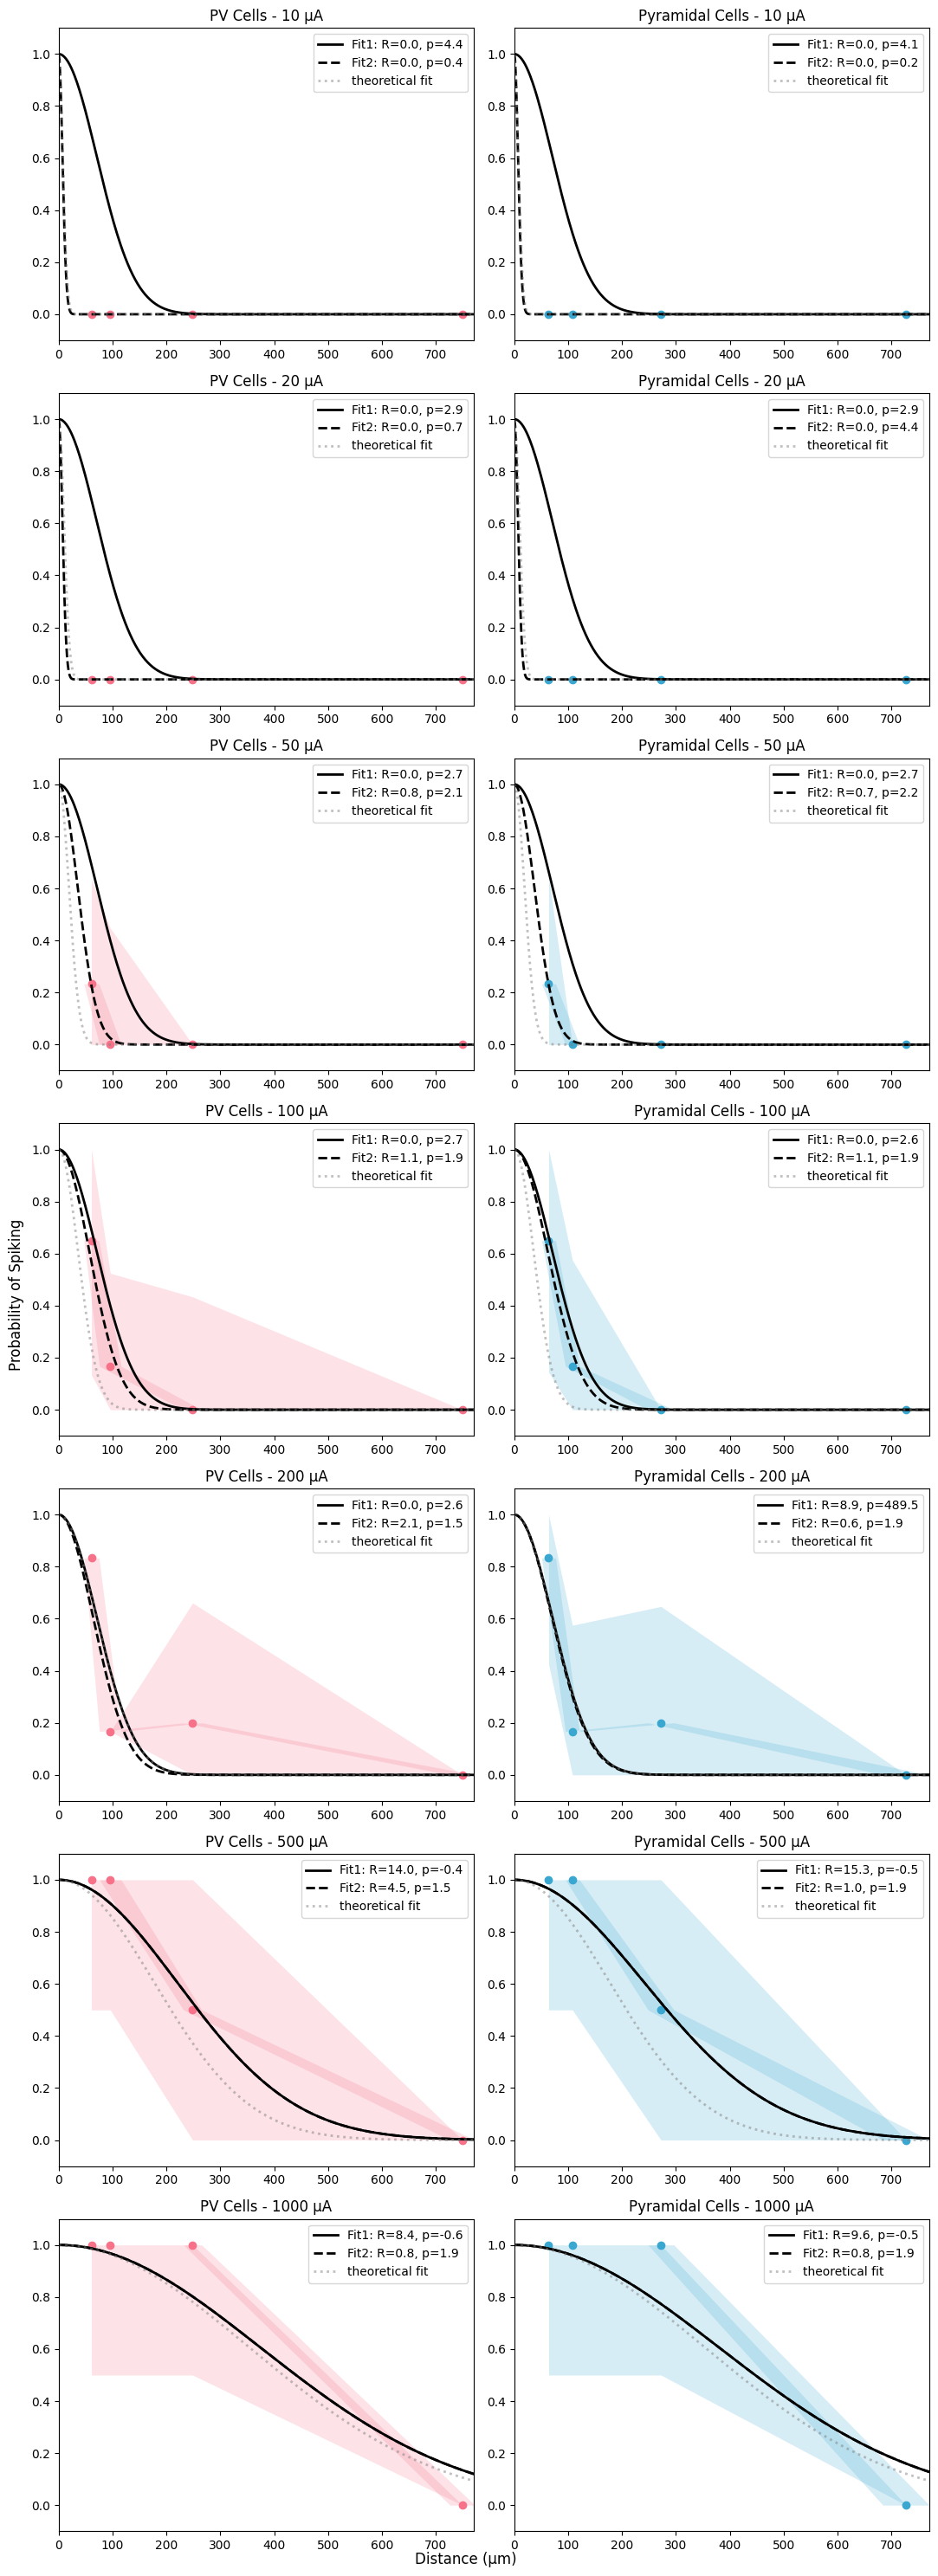

In [235]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()  

x_fit = np.linspace(0, 770, 500)
count = 0
for intensity in intensities:
    ax = axes[count]

    data = pv_data[intensity]
    x, xerr, y, yerr = data["x"], data["xerr"], data["y"], data["yerr"]
    y_low  = np.clip(y - yerr, 0, 1)
    y_high = np.clip(y + yerr, 0, 1)
    x_low = np.clip(x - xerr, 0, 800)
    x_high = np.clip(x + xerr, 0, 800)
    ax.scatter(x, y, color=palette[0])
    ax.fill_between(x, y_low, y_high, color=palette[0], alpha=0.2, linewidth=0)
    ax.fill_betweenx(y, x_low, x_high, color=palette[0], alpha=0.2, linewidth=0)

    R1, p1 = pv_fits1[intensity][0], pv_fits1[intensity][1]
    R2, p2 = pv_fits2[intensity][0], pv_fits2[intensity][1]

    ax.plot(x_fit, gauss1(x_fit, intensity*1000, R1, p1), label=f"Fit1: R={R1:.1f}, p={p1:.1f}", linewidth=2, color="k")
    ax.plot(x_fit, gauss2(x_fit, intensity*1000, R2, p2), label=f"Fit2: R={R2:.1f}, p={p2:.1f}", linewidth=2, color="k", linestyle='dashed')
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 2), label=f"theoretical fit", linewidth=2, color="gray", alpha=0.5, linestyle='dotted')

    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

    ax = axes[count]

    data = pyr_data[intensity]
    x, xerr, y, yerr = data["x"], data["xerr"], data["y"], data["yerr"]
    y_low  = np.clip(y - yerr, 0, 1)
    y_high = np.clip(y + yerr, 0, 1)
    x_low = np.clip(x - xerr, 0, 800)
    x_high = np.clip(x + xerr, 0, 800)
    ax.scatter(x, y, color=palette[5])
    ax.fill_between(x, y_low, y_high, color=palette[5], alpha=0.2, linewidth=0)
    ax.fill_betweenx(y, x_low, x_high, color=palette[5], alpha=0.2, linewidth=0)

    R1, p1 = pyr_fits1[intensity][0], pyr_fits1[intensity][1]
    R2, p2 = pyr_fits2[intensity][0], pyr_fits2[intensity][1]
    ax.plot(x_fit, gauss1(x_fit, intensity*1000, R1, p1), label=f"Fit1: R={R1:.1f}, p={p1:.1f}", linewidth=2, color="k")
    ax.plot(x_fit, gauss2(x_fit, intensity*1000, R2, p2), label=f"Fit2: R={R2:.1f}, p={p2:.1f}", linewidth=2, color="k", linestyle='dashed')
    ax.plot(x_fit, gauss(x_fit, intensity*1000, 0.5, 2), label=f"theoretical fit", linewidth=2, color="gray", alpha=0.5, linestyle='dotted')

    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()

    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()

# chatgpt fitting

In [19]:
def sig(x, x0, k):
    return 1 / (1 + np.exp(k * (x - x0)))

In [20]:
def guess_params(x, y):
    # x0 = distance where y is closest to 0.5
    idx = np.argmin(np.abs(y - 0.5))
    x0_guess = x[idx]

    # slope guess: approximate derivative around midpoint
    # avoids insane slopes
    k_guess = 1 / (0.25 * (np.max(x) - np.min(x)))

    return [x0_guess, k_guess]

In [21]:
def fit_sigmoid(x, y, yerr=None):
    p0 = guess_params(x, y)

    # bounds keep parameters reasonable
    # x0 must be inside measured range
    # k must be positive but limited
    bounds = (
        [np.min(x), 0],   # lower bounds: x0 >= min(x), k >= 0
        [np.max(x), 5]    # upper bounds: x0 <= max(x), k <= 5
    )

    params, cov = curve_fit(
        sig,
        x, y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=True if yerr is not None else False,
        bounds=bounds,
        maxfev=20000
    )

    return params, cov



In [22]:
pyr_fits = {}
pv_fits = {}

for intensity, vals in pyr_data.items():
    x = vals["x"]
    y = vals["y"]
    yerr = vals.get("sd", None)  # IF you stored ±std dev

    pyr_fits[intensity], _ = fit_sigmoid(x, y, yerr)

for intensity, vals in pv_data.items():
    x = vals["x"]
    y = vals["y"]
    yerr = vals.get("sd", None)

    pv_fits[intensity], _ = fit_sigmoid(x, y, yerr)

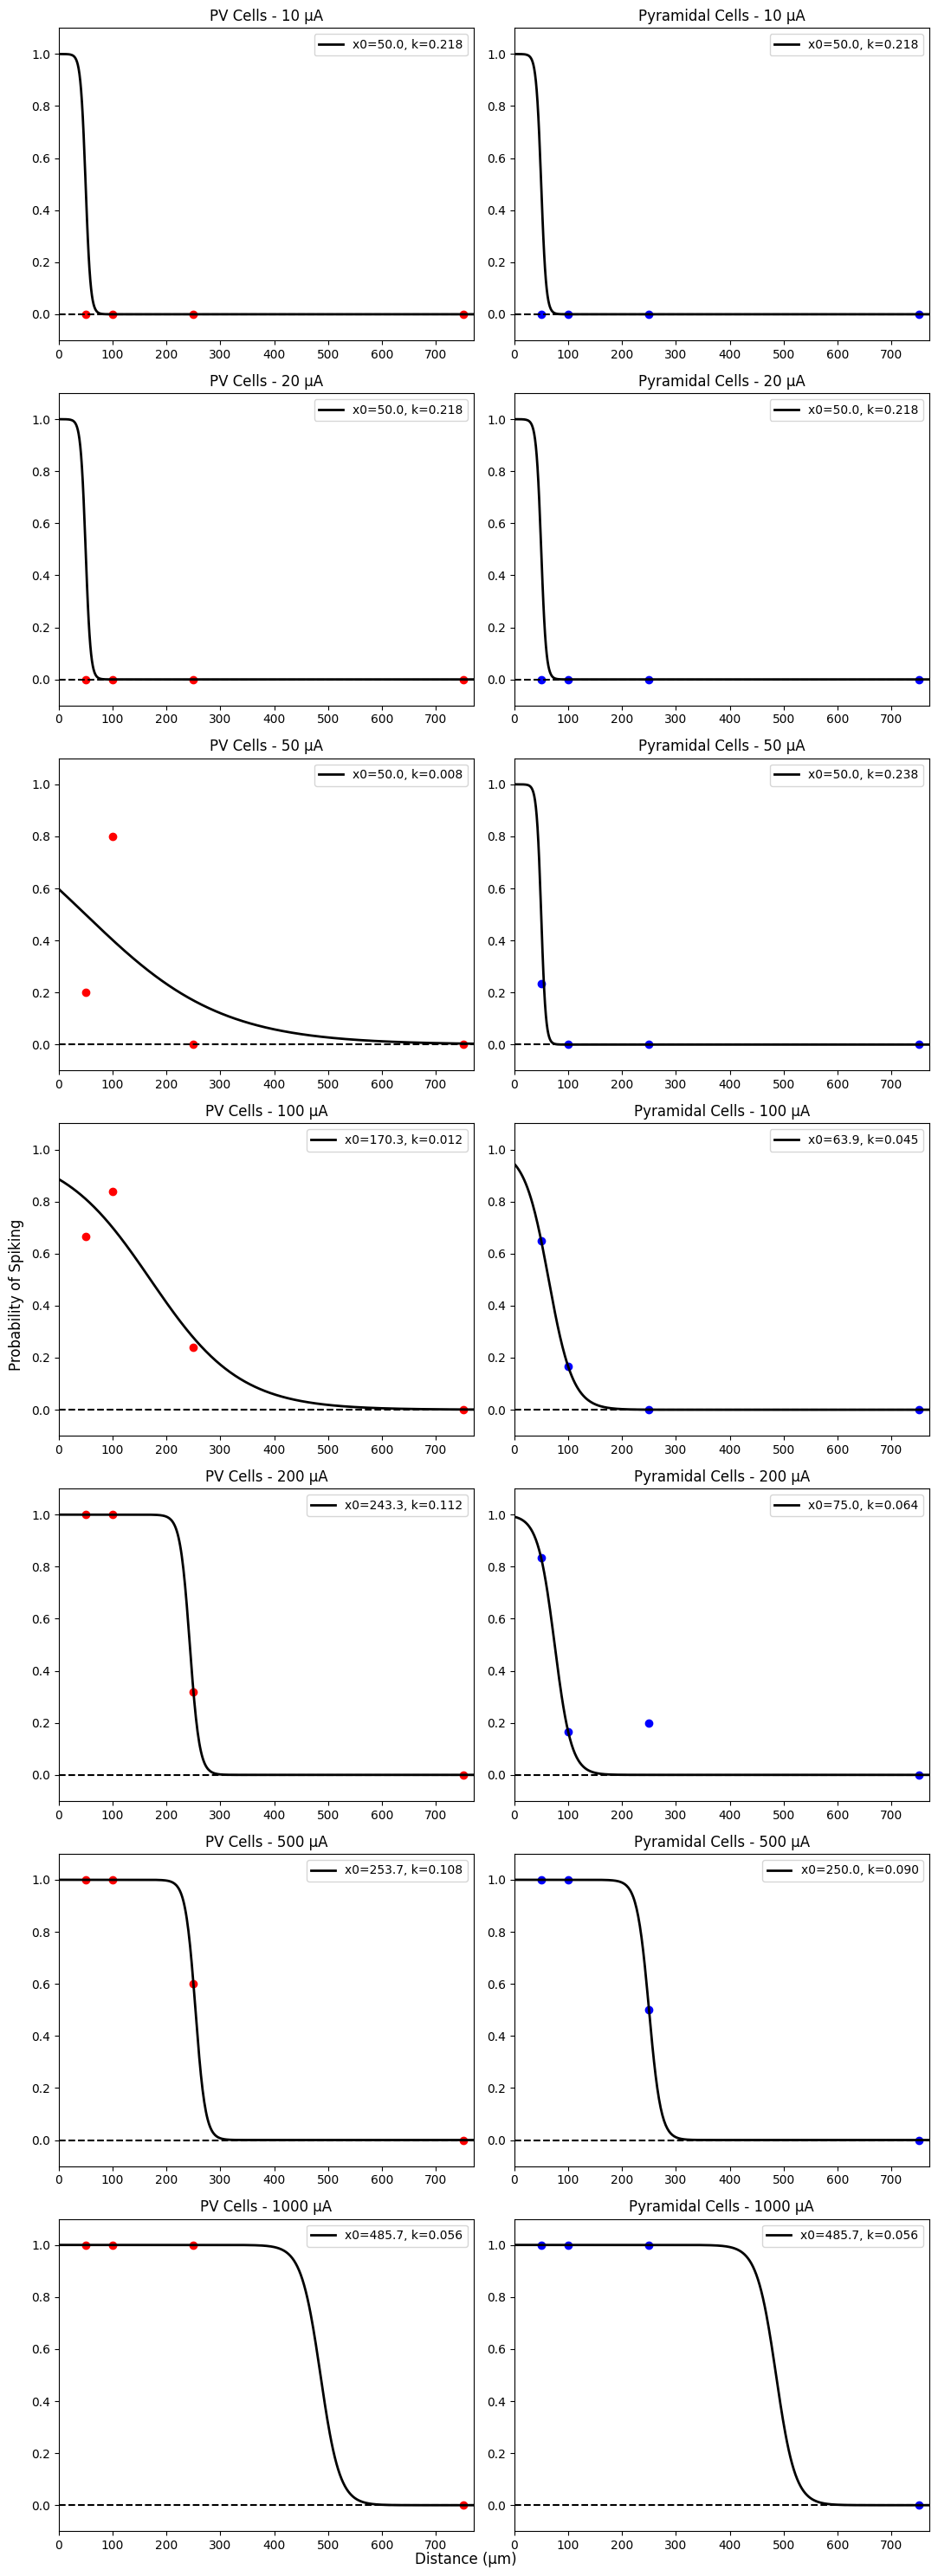

In [12]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(11, 30))
axes = axes.flatten()

x_fit = np.linspace(0, 770, 500)
count = 0

for intensity in intensities:
    # PV PLOT ---------------------------------------------------
    ax = axes[count]
    data = pv_data[intensity]

    ax.scatter(data["x"], data["y"], color='red')

    x0, k = pv_fits[intensity]
    ax.plot(
        x_fit,
        sig(x_fit, x0, k),
        linewidth=2,
        color="k",
        label=f"x0={x0:.1f}, k={k:.3f}"
    )

    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"PV Cells - {intensity*1000:.0f} μA")
    ax.legend()
    count += 1

    ax = axes[count]
    data = pyr_data[intensity]

    ax.scatter(data["x"], data["y"], color='blue')

    x0, k = pyr_fits[intensity]
    ax.plot(
        x_fit,
        sig(x_fit, x0, k),
        linewidth=2,
        color="k",
        label=f"x0={x0:.1f}, k={k:.3f}"
    )

    ax.axhline(0, color='k', linestyle='dashed')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, 770)
    ax.set_title(f"Pyramidal Cells - {intensity*1000:.0f} μA")
    ax.legend()
    count += 1

fig.supylabel("Probability of Spiking")
fig.supxlabel("Distance (μm)")
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()
